[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/zhiyunli/cpsc5610-labs/blob/main/week8/lab_rnn_forecast.ipynb)

# Week 8 Lab: RNNs and Time-Series Forecasting

**CPSC 5610 — Deep Learning**

In this lab you'll build, train, and evaluate **recurrent neural networks** on a
synthetic stock-price series, and compare them against simple baselines.

By the end of the lab you will be able to:

1. Generate a synthetic multivariate-flavored time series and split it for forecasting.
2. Build a **sliding-window dataset** with PyTorch's `Dataset` / `DataLoader`.
3. Implement two simple baselines (naive last-value and linear regression on the window) — and *beat* them.
4. Train a **plain RNN** in PyTorch (`nn.RNN`) for **single-step** forecasting.
5. Compare against a **deep RNN** (stacked layers).
6. Extend to **multi-step** forecasting with two strategies: *iterative* and *seq-to-vec*.


## 1. Setup

We'll use **PyTorch**, **NumPy**, and **Matplotlib**. The whole lab runs comfortably on CPU
in a few minutes — no GPU needed. We seed everything for reproducibility.


In [19]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

SEED = 5610
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| device:', device)


PyTorch 2.10.0+cpu | device: cpu


## 2. Generate a synthetic stock series

Real stock data is noisy, non-stationary, and hard to license cleanly. For pedagogy we
generate a **stationary** synthetic series: a fixed level, a yearly seasonal cycle, a
weekly cycle, an AR(1) momentum term (for "stock-like" autocorrelation), and Gaussian
noise.

> **Why stationary?**  When the training distribution looks very different from the
> test distribution (e.g. a strong upward trend), standardization can't save the model
> — it has never seen those values. We'll see this in a moment; for now we keep things
> clean.

The function below returns a 1-D array of length `n` plus a `time` axis (in "days").
Treat each value as a daily closing price.

$$
\text{price}(t) \;=\; L \;+\; c\sin(2\pi t / 252)\;+\; d\sin(2\pi t / 5)
\;+\; r_t \;+\; \sigma\,\varepsilon_t,
\qquad
r_t = \rho\,r_{t-1} + \eta_t
$$

(252 = trading days/year, 5 = trading days/week.)


In [20]:
def make_stock_series(n=2000, seed=0):
    rng = np.random.default_rng(seed)
    t = np.arange(n)
    level    = 100.0
    yearly   =  6.0 * np.sin(2 * np.pi * t / 252)
    weekly   =  1.5 * np.sin(2 * np.pi * t / 5)
    # AR(1) momentum:  r_t = rho * r_{t-1} + eta_t
    rho = 0.90
    eps = rng.standard_normal(n) * 0.5
    r = np.zeros(n)
    for i in range(1, n):
        r[i] = rho * r[i-1] + eps[i]
    noise = rng.standard_normal(n) * 0.5
    price = level + yearly + weekly + r + noise
    return t, price.astype(np.float32)

t, price = make_stock_series(n=2000, seed=SEED)
print('series shape:', price.shape, '| min/max:', price.min(), price.max())


series shape: (2000,) | min/max: 89.946335 109.86782


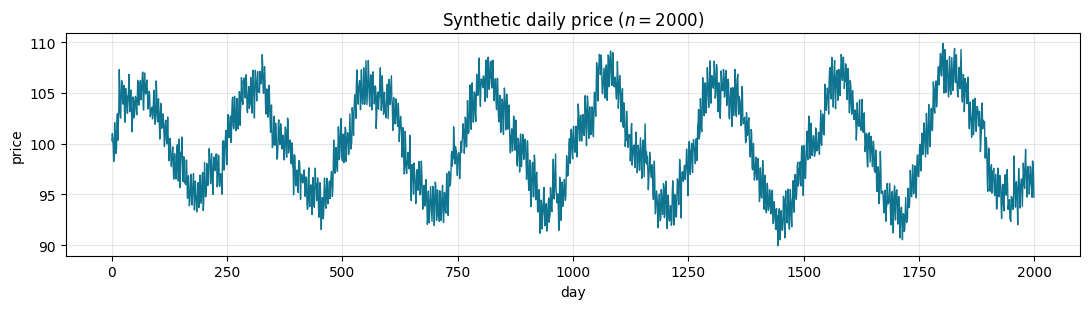

In [21]:
plt.figure(figsize=(11, 3.2))
plt.plot(t, price, color='#0e7490', lw=1.0)
plt.title('Synthetic daily price ($n=2000$)')
plt.xlabel('day'); plt.ylabel('price'); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()


## 3. Train / val / test split (chronological)

**Never shuffle time series before splitting.** Future samples must stay in the test set,
or you leak the answer.

We'll use 70 / 15 / 15.


train/val/test sizes: 1400 300 300


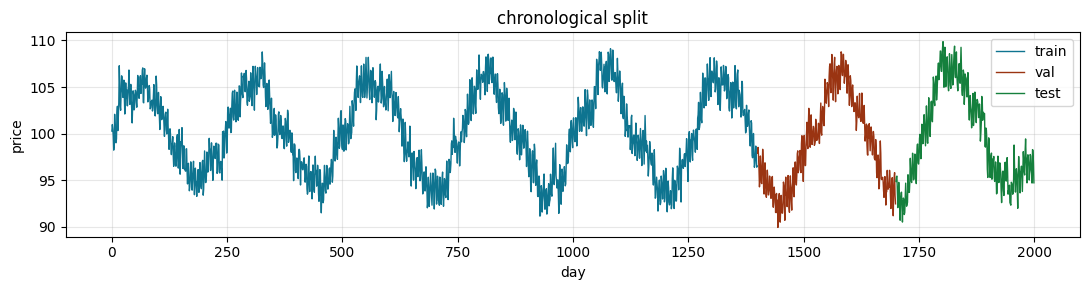

In [22]:
n = len(price)
i_train = int(0.70 * n)
i_val   = int(0.85 * n)

train = price[:i_train]
val   = price[i_train:i_val]
test  = price[i_val:]
print('train/val/test sizes:', len(train), len(val), len(test))

fig, ax = plt.subplots(figsize=(11, 3.0))
ax.plot(t[:i_train],         train, color='#0e7490', lw=1.0, label='train')
ax.plot(t[i_train:i_val],    val,   color='#9a3412', lw=1.0, label='val')
ax.plot(t[i_val:],           test,  color='#15803d', lw=1.0, label='test')
ax.set_title('chronological split'); ax.set_xlabel('day'); ax.set_ylabel('price')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()


We standardize using **train statistics only** (no peeking).


In [23]:
mu, sd = train.mean(), train.std()
train_s = (train - mu) / sd
val_s   = (val   - mu) / sd
test_s  = (test  - mu) / sd
print(f'train mean={mu:.2f}  std={sd:.2f}  -> standardized range '
      f'[{train_s.min():.2f}, {train_s.max():.2f}]')


train mean=100.36  std=4.26  -> standardized range [-2.16, 2.05]


## 4. Sliding-window dataset

A forecasting task needs **(window, target)** pairs. Given the past `W` values we
predict the next one (single-step). PyTorch's `Dataset` API makes this clean:


In [24]:
class WindowDataset(Dataset):
    """Single-step: window of length W -> next value."""
    def __init__(self, series, window=50):
        self.series = series
        self.W = window

    def __len__(self):
        return len(self.series) - self.W

    def __getitem__(self, i):
        x = self.series[i : i + self.W]
        y = self.series[i + self.W]
        # shape x: (W, 1)  shape y: (1,)
        return (torch.from_numpy(x).unsqueeze(-1),
                torch.tensor([y], dtype=torch.float32))


W = 50
batch_size = 32

ds_train = WindowDataset(train_s, window=W)
ds_val   = WindowDataset(val_s,   window=W)
ds_test  = WindowDataset(test_s,  window=W)

dl_train = DataLoader(ds_train, batch_size=batch_size, shuffle=True)
dl_val   = DataLoader(ds_val,   batch_size=batch_size, shuffle=False)
dl_test  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False)

xb, yb = next(iter(dl_train))
print('one batch  x:', tuple(xb.shape), '  y:', tuple(yb.shape))


one batch  x: (32, 50, 1)   y: (32, 1)


## 5. Baselines — *the axiom of forecasting*

> **Always quote baselines.** A model that doesn't beat naive doesn't beat doing nothing.

Two cheap baselines:

- **Naive**: $\hat{y}_{t+1} = y_t$ — last value.
- **Linear**: fit a single `Linear(W, 1)` on the standardized window. This is one MLP
  layer, no nonlinearity, no recurrence. A surprisingly strong floor.

We'll report **MAE** in *unstandardized* units (price), so the numbers are interpretable.


In [25]:
def unstd(y):
    return y * sd + mu

def naive_mae(loader):
    se = 0.0; n = 0
    for x, y in loader:
        # x shape (B, W, 1).  last value is x[:, -1, 0]
        pred = x[:, -1, 0:1]
        se += (unstd(pred) - unstd(y)).abs().sum().item()
        n  += y.shape[0]
    return se / n

mae_naive_val = naive_mae(dl_val)
mae_naive_tst = naive_mae(dl_test)
print(f'naive  baseline   val MAE = {mae_naive_val:.3f}  test MAE = {mae_naive_tst:.3f}')


naive  baseline   val MAE = 1.290  test MAE = 1.328


In [26]:
class LinearWindow(nn.Module):
    def __init__(self, window):
        super().__init__()
        self.fc = nn.Linear(window, 1)
    def forward(self, x):                  # x: (B, W, 1)
        return self.fc(x.squeeze(-1))      # (B, 1)


def train_model(model, dl_tr, dl_va, epochs=15, lr=1e-3):
    opt = torch.optim.Adam(model.parameters(), lr=lr)
    lossf = nn.MSELoss()
    hist = {'tr': [], 'va': []}
    for ep in range(epochs):
        model.train()
        tr_loss = 0.0; ntr = 0
        for x, y in dl_tr:
            x, y = x.to(device), y.to(device)
            opt.zero_grad()
            pred = model(x)
            loss = lossf(pred, y)
            loss.backward()
            opt.step()
            tr_loss += loss.item() * y.shape[0]; ntr += y.shape[0]
        model.eval()
        va_loss = 0.0; nva = 0
        with torch.no_grad():
            for x, y in dl_va:
                x, y = x.to(device), y.to(device)
                pred = model(x)
                va_loss += lossf(pred, y).item() * y.shape[0]; nva += y.shape[0]
        hist['tr'].append(tr_loss / ntr); hist['va'].append(va_loss / nva)
        print(f'  ep {ep+1:02d}  train MSE {hist["tr"][-1]:.4f}  val MSE {hist["va"][-1]:.4f}')
    return hist


def eval_mae(model, loader):
    model.eval()
    se = 0.0; n = 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x)
            se += (unstd(pred.cpu()) - unstd(y.cpu())).abs().sum().item()
            n  += y.shape[0]
    return se / n


lin = LinearWindow(W).to(device)
print('linear baseline ...')
_ = train_model(lin, dl_train, dl_val, epochs=10, lr=1e-2)
mae_lin_val = eval_mae(lin, dl_val)
mae_lin_tst = eval_mae(lin, dl_test)
print(f'linear baseline   val MAE = {mae_lin_val:.3f}  test MAE = {mae_lin_tst:.3f}')


linear baseline ...
  ep 01  train MSE 0.2205  val MSE 0.0614
  ep 02  train MSE 0.0678  val MSE 0.0517
  ep 03  train MSE 0.0537  val MSE 0.0432
  ep 04  train MSE 0.0495  val MSE 0.0556
  ep 05  train MSE 0.0476  val MSE 0.0376
  ep 06  train MSE 0.0423  val MSE 0.0365
  ep 07  train MSE 0.0419  val MSE 0.0481
  ep 08  train MSE 0.0432  val MSE 0.0389
  ep 09  train MSE 0.0469  val MSE 0.0374
  ep 10  train MSE 0.0450  val MSE 0.0353
linear baseline   val MAE = 0.634  test MAE = 0.707


## 6. A plain RNN forecaster

The simplest recurrent model: one `nn.RNN` layer, then a linear head on the final
hidden state.

Shapes:
- input:   `(B, W, 1)`
- hidden:  `(1, B, hidden)` returned as `h_n`
- output:  `(B, 1)` — single-step prediction


In [27]:
class SimpleRNN(nn.Module):
    def __init__(self, hidden=32):
        super().__init__()
        self.rnn  = nn.RNN(input_size=1, hidden_size=hidden, batch_first=True)
        self.head = nn.Linear(hidden, 1)

    def forward(self, x):                  # x: (B, W, 1)
        _, h_n = self.rnn(x)               # h_n: (1, B, H)
        return self.head(h_n.squeeze(0))   # (B, 1)


rnn = SimpleRNN(hidden=32).to(device)
print(rnn)
print('params:', sum(p.numel() for p in rnn.parameters()))


SimpleRNN(
  (rnn): RNN(1, 32, batch_first=True)
  (head): Linear(in_features=32, out_features=1, bias=True)
)
params: 1153


In [28]:
print('plain RNN ...')
hist_rnn = train_model(rnn, dl_train, dl_val, epochs=15, lr=1e-3)
mae_rnn_val = eval_mae(rnn, dl_val)
mae_rnn_tst = eval_mae(rnn, dl_test)
print(f'plain RNN         val MAE = {mae_rnn_val:.3f}  test MAE = {mae_rnn_tst:.3f}')


plain RNN ...
  ep 01  train MSE 0.6796  val MSE 0.2059
  ep 02  train MSE 0.1639  val MSE 0.1558
  ep 03  train MSE 0.1406  val MSE 0.1352
  ep 04  train MSE 0.1301  val MSE 0.1213
  ep 05  train MSE 0.1173  val MSE 0.1077
  ep 06  train MSE 0.0982  val MSE 0.0829
  ep 07  train MSE 0.0595  val MSE 0.0494
  ep 08  train MSE 0.0523  val MSE 0.0513
  ep 09  train MSE 0.0500  val MSE 0.0434
  ep 10  train MSE 0.0469  val MSE 0.0418
  ep 11  train MSE 0.0450  val MSE 0.0399
  ep 12  train MSE 0.0446  val MSE 0.0384
  ep 13  train MSE 0.0439  val MSE 0.0384
  ep 14  train MSE 0.0431  val MSE 0.0372
  ep 15  train MSE 0.0422  val MSE 0.0371
plain RNN         val MAE = 0.651  test MAE = 0.727


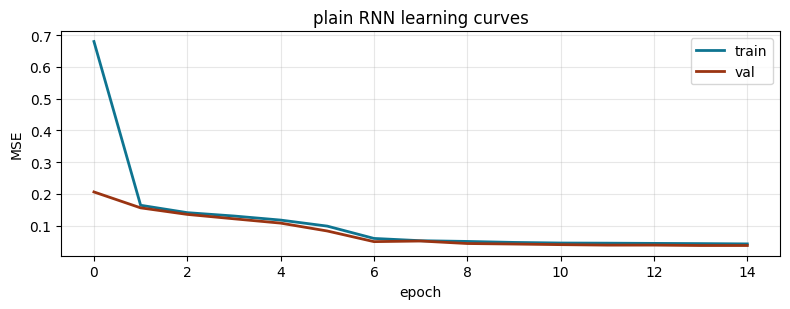

In [29]:
# learning curves
plt.figure(figsize=(8, 3.2))
plt.plot(hist_rnn['tr'], label='train', color='#0e7490', lw=2)
plt.plot(hist_rnn['va'], label='val',   color='#9a3412', lw=2)
plt.title('plain RNN learning curves'); plt.xlabel('epoch'); plt.ylabel('MSE')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


## 7. Stacking layers — deep RNN

`nn.RNN` takes a `num_layers` argument. Two or three layers can help; beyond that
the gradient struggles and you should reach for **LSTM / GRU** (next lecture).


In [30]:
class DeepRNN(nn.Module):
    def __init__(self, hidden=32, layers=2):
        super().__init__()
        self.rnn  = nn.RNN(1, hidden, num_layers=layers, batch_first=True)
        self.head = nn.Linear(hidden, 1)
    def forward(self, x):
        _, h_n = self.rnn(x)               # h_n: (layers, B, H)
        return self.head(h_n[-1])          # use the top layer's final hidden


deep = DeepRNN(hidden=32, layers=2).to(device)
print('deep RNN (2 layers) ...')
hist_deep = train_model(deep, dl_train, dl_val, epochs=15, lr=1e-3)
mae_deep_val = eval_mae(deep, dl_val)
mae_deep_tst = eval_mae(deep, dl_test)
print(f'deep RNN (2L)     val MAE = {mae_deep_val:.3f}  test MAE = {mae_deep_tst:.3f}')


deep RNN (2 layers) ...
  ep 01  train MSE 0.3816  val MSE 0.1594
  ep 02  train MSE 0.1124  val MSE 0.0746
  ep 03  train MSE 0.0587  val MSE 0.0514
  ep 04  train MSE 0.0532  val MSE 0.0512
  ep 05  train MSE 0.0521  val MSE 0.0463
  ep 06  train MSE 0.0470  val MSE 0.0426
  ep 07  train MSE 0.0464  val MSE 0.0415
  ep 08  train MSE 0.0495  val MSE 0.0454
  ep 09  train MSE 0.0456  val MSE 0.0401
  ep 10  train MSE 0.0441  val MSE 0.0404
  ep 11  train MSE 0.0446  val MSE 0.0372
  ep 12  train MSE 0.0417  val MSE 0.0372
  ep 13  train MSE 0.0409  val MSE 0.0363
  ep 14  train MSE 0.0448  val MSE 0.0373
  ep 15  train MSE 0.0412  val MSE 0.0414
deep RNN (2L)     val MAE = 0.696  test MAE = 0.749


## 8. Results so far

A simple comparison table for single-step forecasting.


In [31]:
results = [
    ('naive (last value)',  mae_naive_val, mae_naive_tst),
    ('linear regression',   mae_lin_val,   mae_lin_tst),
    ('plain RNN',           mae_rnn_val,   mae_rnn_tst),
    ('deep RNN (2 layers)', mae_deep_val,  mae_deep_tst),
]
print(f'{"model":<22}  {"val MAE":>10}  {"test MAE":>10}')
print('-' * 48)
for name, va, te in results:
    print(f'{name:<22}  {va:>10.3f}  {te:>10.3f}')


model                      val MAE    test MAE
------------------------------------------------
naive (last value)           1.290       1.328
linear regression            0.634       0.707
plain RNN                    0.651       0.727
deep RNN (2 layers)          0.696       0.749


**Discussion** (write 2-3 sentences):
- Did your RNN beat both baselines on val *and* test?
- If the linear baseline is close to the RNN, what does that suggest about the task?


## 9. Multi-step forecasting

Single-step is the easy mode. Real-world forecasting usually asks for a **horizon**
of $H$ values. We compare two strategies:

| strategy   | how it works                                       | failure mode               |
|------------|----------------------------------------------------|----------------------------|
| iterative  | predict one step, feed it back, repeat $H$ times   | **errors compound**        |
| seq-to-vec | `nn.Linear(hidden, H)` — emit all $H$ at once     | needs more data; coherent  |

Pick a horizon and see how the strategies behave.


In [32]:
H = 10  # forecast horizon

# Build a multi-step dataset: window -> next H values
class MultiStepDataset(Dataset):
    def __init__(self, series, window=50, horizon=10):
        self.series = series
        self.W = window
        self.H = horizon
    def __len__(self):
        return len(self.series) - self.W - self.H + 1
    def __getitem__(self, i):
        x = self.series[i : i + self.W]
        y = self.series[i + self.W : i + self.W + self.H]
        return (torch.from_numpy(x).unsqueeze(-1),
                torch.from_numpy(y).float())


ms_train = MultiStepDataset(train_s, window=W, horizon=H)
ms_val   = MultiStepDataset(val_s,   window=W, horizon=H)
ms_test  = MultiStepDataset(test_s,  window=W, horizon=H)

dl_ms_train = DataLoader(ms_train, batch_size=batch_size, shuffle=True)
dl_ms_val   = DataLoader(ms_val,   batch_size=batch_size, shuffle=False)
dl_ms_test  = DataLoader(ms_test,  batch_size=batch_size, shuffle=False)

xb, yb = next(iter(dl_ms_train))
print('multi-step batch  x:', tuple(xb.shape), '  y:', tuple(yb.shape))


multi-step batch  x: (32, 50, 1)   y: (32, 10)


### 9a. Iterative forecasting (reuse the single-step RNN)

We already trained `rnn` for single-step. For an $H$-step horizon, predict step 1,
**append it to the window**, slide the window forward, predict step 2, and so on.


In [33]:
def iterative_forecast(model, x, horizon):
    """x: (B, W, 1) -- returns (B, H).  Uses model autoregressively."""
    model.eval()
    cur = x.clone()
    outs = []
    with torch.no_grad():
        for _ in range(horizon):
            p = model(cur)                  # (B, 1)
            outs.append(p)
            cur = torch.cat([cur[:, 1:, :], p.unsqueeze(-1)], dim=1)
    return torch.cat(outs, dim=1)           # (B, H)


def horizon_mae(forecast_fn, loader):
    se = 0.0; n = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        pred = forecast_fn(x)               # (B, H)
        se += (unstd(pred.cpu()) - unstd(y.cpu())).abs().sum().item()
        n  += y.numel()
    return se / n


mae_iter_val = horizon_mae(lambda x: iterative_forecast(rnn, x, H), dl_ms_val)
mae_iter_tst = horizon_mae(lambda x: iterative_forecast(rnn, x, H), dl_ms_test)
print(f'iterative ({H}-step)   val MAE = {mae_iter_val:.3f}  test MAE = {mae_iter_tst:.3f}')


iterative (10-step)   val MAE = 1.066  test MAE = 1.140


### 9b. Seq-to-vec forecasting (train one model that emits all $H$ at once)

The same RNN backbone but the head is `nn.Linear(hidden, H)`. One forward pass per
horizon — no compounding.


In [34]:
class Seq2VecForecaster(nn.Module):
    def __init__(self, hidden=32, horizon=10):
        super().__init__()
        self.rnn  = nn.RNN(1, hidden, batch_first=True)
        self.head = nn.Linear(hidden, horizon)
    def forward(self, x):                   # x: (B, W, 1)
        _, h_n = self.rnn(x)
        return self.head(h_n.squeeze(0))    # (B, H)


s2v = Seq2VecForecaster(hidden=32, horizon=H).to(device)
print('seq2vec multi-step RNN ...')
hist_s2v = train_model(s2v, dl_ms_train, dl_ms_val, epochs=15, lr=1e-3)
mae_s2v_val = horizon_mae(lambda x: s2v(x), dl_ms_val)
mae_s2v_tst = horizon_mae(lambda x: s2v(x), dl_ms_test)
print(f'seq2vec ({H}-step)     val MAE = {mae_s2v_val:.3f}  test MAE = {mae_s2v_tst:.3f}')


seq2vec multi-step RNN ...
  ep 01  train MSE 0.6406  val MSE 0.3306
  ep 02  train MSE 0.2150  val MSE 0.1837
  ep 03  train MSE 0.1713  val MSE 0.1651
  ep 04  train MSE 0.1648  val MSE 0.1599
  ep 05  train MSE 0.1614  val MSE 0.1546
  ep 06  train MSE 0.1566  val MSE 0.1490
  ep 07  train MSE 0.1489  val MSE 0.1395
  ep 08  train MSE 0.1327  val MSE 0.1166
  ep 09  train MSE 0.1130  val MSE 0.1062
  ep 10  train MSE 0.1079  val MSE 0.1004
  ep 11  train MSE 0.1044  val MSE 0.0999
  ep 12  train MSE 0.1032  val MSE 0.0980
  ep 13  train MSE 0.1025  val MSE 0.0962
  ep 14  train MSE 0.1003  val MSE 0.0952
  ep 15  train MSE 0.0996  val MSE 0.0932
seq2vec (10-step)     val MAE = 1.035  test MAE = 1.121


## 10. Compare strategies visually

Pick one test window and plot:
- the input window,
- the ground-truth next $H$ values,
- the **iterative** forecast,
- the **seq-to-vec** forecast.


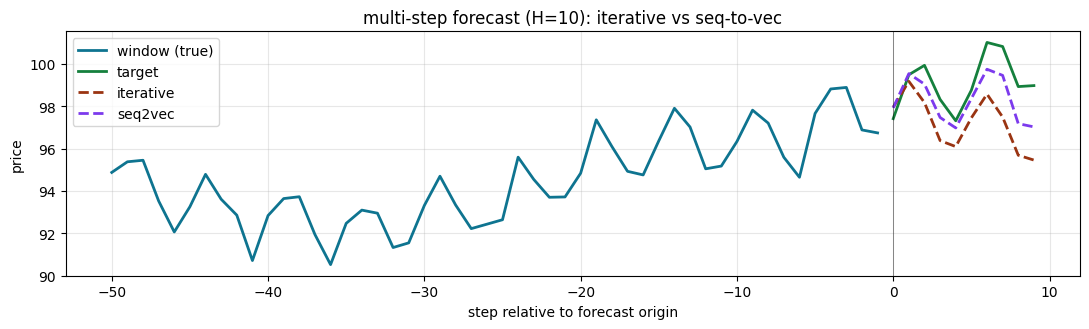

In [35]:
# Grab one batch from test and plot the first sample
x_ms, y_ms = next(iter(dl_ms_test))
x_ms, y_ms = x_ms.to(device), y_ms.to(device)

pred_iter = iterative_forecast(rnn, x_ms, H).cpu().numpy()
pred_s2v  = s2v(x_ms).detach().cpu().numpy()
x_np  = x_ms.cpu().numpy()
y_np  = y_ms.cpu().numpy()

i = 0
window_t = np.arange(-W, 0)
horizon_t = np.arange(0, H)
plt.figure(figsize=(11, 3.4))
plt.plot(window_t, unstd(x_np[i, :, 0]), color='#0e7490', lw=2, label='window (true)')
plt.plot(horizon_t, unstd(y_np[i]),       color='#15803d', lw=2, label='target')
plt.plot(horizon_t, unstd(pred_iter[i]),  color='#9a3412', lw=2, ls='--', label='iterative')
plt.plot(horizon_t, unstd(pred_s2v[i]),   color='#7c3aed', lw=2, ls='--', label='seq2vec')
plt.axvline(0, color='black', lw=0.6, alpha=0.5)
plt.title(f'multi-step forecast (H={H}): iterative vs seq-to-vec')
plt.xlabel('step relative to forecast origin'); plt.ylabel('price')
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


In [36]:
print(f'{"strategy":<22}  {"val MAE":>10}  {"test MAE":>10}')
print('-' * 48)
for name, va, te in [
    ('iterative (reuse RNN)',  mae_iter_val, mae_iter_tst),
    ('seq2vec (joint head)',   mae_s2v_val,  mae_s2v_tst),
]:
    print(f'{name:<22}  {va:>10.3f}  {te:>10.3f}')


strategy                   val MAE    test MAE
------------------------------------------------
iterative (reuse RNN)        1.066       1.140
seq2vec (joint head)         1.035       1.121


## 11. Exercises

Pick **two** of the following and report your findings in 3-5 sentences each
(plot if helpful):

1. **Window size.** Vary `W` over `{10, 30, 50, 100}`. Plot val MAE vs `W`.
   Is more history always better?
2. **Hidden size.** Vary `hidden` over `{8, 16, 32, 64}`. Plot val MAE vs `hidden`.
   Where does it plateau?
3. **Truncated BPTT.** Train with much longer windows (`W=200`) and observe
   train time and val MAE. Where does it start to break?
4. **Seasonality.** Make the synthetic series with no yearly component
   (`c=0` in `make_stock_series`). Do the relative orderings of the models change?
5. **Bigger horizon.** Set `H=30`. Does the gap between *iterative* and *seq2vec* widen?

> Bonus: add a 3rd baseline — exponentially-weighted moving average. Does it beat naive?


---
### Wrap-up

What you built:
- a reproducible synthetic-series generator,
- a sliding-window dataset,
- two baselines (naive and linear),
- a plain `nn.RNN` single-step forecaster,
- a stacked `nn.RNN` deep forecaster,
- iterative *and* seq-to-vec multi-step strategies.

**Next lecture** swaps the plain RNN for **LSTM** and **GRU** cells — same data,
smarter cells. The lab for Lecture 2 will reuse this exact dataset so you can see
the apples-to-apples improvement.
